# CERT Insider Threat — Full Pipeline


## Imports

In [1]:
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import rankdata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import tensorflow as tf
import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
    f1_score,
)

from xgboost import XGBClassifier


## Load All Datasets

In [2]:
data_folder = r"D:\r4.2"

print('Loading datasets...')
logon_logs  = pd.read_csv(os.path.join(data_folder, 'logon.csv'),       parse_dates=['date'])
device_logs = pd.read_csv(os.path.join(data_folder, 'device.csv'),      parse_dates=['date'])
email_logs  = pd.read_csv(os.path.join(data_folder, 'email.csv'),       parse_dates=['date'])
file_logs   = pd.read_csv(os.path.join(data_folder, 'file.csv'),        parse_dates=['date'])
web_logs    = pd.read_csv(os.path.join(data_folder, 'http_erased.csv'), parse_dates=['date'])  # some columns removed due to resource constraints

print(f'  logon:  {logon_logs.shape}')
print(f'  email:  {email_logs.shape}')
print(f'  device: {device_logs.shape}')
print(f'  file:   {file_logs.shape}')
print(f'  http:   {web_logs.shape}')

all_users = pd.DataFrame({'user': pd.concat([
    logon_logs['user'], email_logs['user'], device_logs['user'],
    file_logs['user'], web_logs['user']
]).unique()})

Loading datasets...
  logon:  (854859, 5)
  email:  (2629979, 11)
  device: (405380, 5)
  file:   (445581, 6)
  http:   (1048575, 5)


## Merge and Clean Activity Logs

In [3]:
print('\nMerging activity logs...')

# Working on copies so the originals stay intact
logon_clean  = logon_logs.copy()
device_clean = device_logs.copy()
email_clean  = email_logs.copy()
file_clean   = file_logs.copy()
web_clean    = web_logs.copy()

# Standardising the activity labels
logon_clean['activity']  = logon_clean['activity'].str.strip().str.lower()
device_clean['activity'] = 'device'
email_clean['activity']  = 'email'
file_clean['activity']   = 'file'
web_clean['activity']    = 'http'

# Keeping only the three columns we need
columns_to_keep = ['user', 'date', 'activity']
activity_log = pd.concat(
    [
        logon_clean[columns_to_keep],
        device_clean[columns_to_keep],
        email_clean[columns_to_keep],
        file_clean[columns_to_keep],
        web_clean[columns_to_keep],
    ],
    ignore_index=True
)

activity_log = activity_log.sort_values(['user', 'date']).reset_index(drop=True)
activity_log['date']     = pd.to_datetime(activity_log['date'], errors='coerce')
activity_log             = activity_log.dropna(subset=['user', 'date'])
activity_log['activity'] = activity_log['activity'].fillna('unknown')
activity_log['day']      = activity_log['date'].dt.date

# Assigning each event to one of 96 fifteen-minute bins within the day
activity_log['time_bin'] = activity_log['date'].dt.hour * 4 + activity_log['date'].dt.minute // 15

print(f'Merged activity log shape: {activity_log.shape}')

ACTIVITY_TYPES = ['logon', 'logoff', 'email', 'file', 'device', 'http', 'unknown']
NUM_TIME_BINS  = 96   # 24 hours × 4 bins per hour



Merging activity logs...
Merged activity log shape: (5384374, 5)


## Build 96×7 Activity Matrices
For every (user, day) pair construct a `(96, 7)` matrix — 96 fifteen-minute bins × 7 activity types.

In [4]:
# Log1p transform is applied as the matrix is built.
# This compresses extreme outlier counts so that a user with 500 USB
# events in one day no longer dominates normalisation.
# log1p(0) = 0, so empty bins are left at zero.

def build_daily_activity_matrix(
    day_group,
    activity_types=ACTIVITY_TYPES,
    num_bins=NUM_TIME_BINS
):
    """Return a (num_bins, num_activity_types) matrix of log1p event counts."""
    activity_to_index = {activity: idx for idx, activity in enumerate(activity_types)}
    matrix = np.zeros((num_bins, len(activity_types)), dtype=np.float32)

    activity_indices = day_group['activity'].map(activity_to_index).fillna(activity_to_index['unknown']).astype(int)
    bin_indices      = day_group['time_bin'].clip(0, num_bins - 1).astype(int)

    np.add.at(matrix, (bin_indices.values, activity_indices.values), 1)
    return np.log1p(matrix)  # compress counts before returning


print('\nBuilding user-day matrices (log1p transform)...')
user_day_matrices = {}
for (user, day), day_group in tqdm(activity_log.groupby(['user', 'day']), desc='Matrices'):
    user_day_matrices[(user, day)] = build_daily_activity_matrix(day_group)

# Stack into a 3-D array: (num_samples, 96, 7)
sample_keys   = list(user_day_matrices.keys())
activity_cube = np.stack([user_day_matrices[key] for key in sample_keys], axis=0)

print(f'Activity cube shape: {activity_cube.shape}')
print(f'Value range after log1p: [{activity_cube.min():.3f}, {activity_cube.max():.3f}]')



Building user-day matrices (log1p transform)...


Matrices: 100%|██████████| 330452/330452 [11:20<00:00, 485.56it/s]


Activity cube shape: (330452, 96, 7)
Value range after log1p: [0.000, 5.094]


## MinMax Normalisation
Per-sample MinMax normalisation to `[0, 1]`. Used by the supervised models and as a fallback.

In [5]:
num_samples, num_time_bins, num_activity_types = activity_cube.shape

# Flatten each sample to a 1-D vector for per-sample scaling
flat_samples = activity_cube.reshape(num_samples, -1).astype(np.float32)

sample_mins   = flat_samples.min(axis=1, keepdims=True)
sample_maxs   = flat_samples.max(axis=1, keepdims=True)
sample_ranges = np.where(sample_maxs - sample_mins == 0, 1, sample_maxs - sample_mins)

flat_minmax_normalised = (flat_samples - sample_mins) / sample_ranges

# Reshaping it back to image format: (N, H, W, 1) for Conv models
minmax_images = flat_minmax_normalised.reshape(
    num_samples, num_time_bins, num_activity_types, 1
)
print(f'MinMax image tensor shape: {minmax_images.shape}')


MinMax image tensor shape: (330452, 96, 7, 1)


## Per-User Z-Score Normalisation

In [6]:
print('\nComputing per-user z-score normalisation...')

user_baseline_mean = {}
user_baseline_std  = {}

for user in tqdm(activity_log['user'].unique(), desc='User baselines'):
    user_sample_indices = [i for i, key in enumerate(sample_keys) if key[0] == user]
    if len(user_sample_indices) == 0:
        continue
    user_flat_samples          = flat_samples[user_sample_indices]
    user_baseline_mean[user]   = user_flat_samples.mean(axis=0)
    user_baseline_std[user]    = user_flat_samples.std(axis=0) + 1e-8  # avoid division by zero

# Score each day against that user's own baseline
flat_zscores = np.zeros_like(flat_samples)
for i, (user, day) in enumerate(sample_keys):
    if user in user_baseline_mean:
        flat_zscores[i] = (flat_samples[i] - user_baseline_mean[user]) / user_baseline_std[user]
    else:
        flat_zscores[i] = flat_samples[i]

# Clip extreme outliers — anything beyond ±5 std is already very suspicious
flat_zscores = np.clip(flat_zscores, -5, 5)

# CRITICAL: do NOT rescale each sample individually to [0,1] after z-scoring.
# If we did, a benign day (z ≈ 0) and a malicious day (z ≈ 4) would both
# map to [0, 1] and lose the magnitude signal the autoencoder relies on.
# Instead, apply a single GLOBAL linear shift: (z + 5) / 10 → [0, 1].
# This keeps relative magnitudes intact: z=0 (normal) → 0.5, z=+4 (anomalous) → 0.9.
flat_zscores_shifted = (flat_zscores + 5.0) / 10.0   # maps [-5, 5] → [0, 1]

zscore_images = flat_zscores_shifted.reshape(
    num_samples, num_time_bins, num_activity_types, 1
)

print(f'Z-score image tensor shape: {zscore_images.shape}')
print(f'Value range after clip + shift: [{zscore_images.min():.3f}, {zscore_images.max():.3f}]')
print(f'A z=0 day maps to 0.5 — exactly centred')
print(f'A z=+3 (very anomalous) maps to 0.8 — clearly above centre')
print(f'A z=-3 (very inactive)  maps to 0.2 — clearly below centre')



Computing per-user z-score normalisation...


User baselines: 100%|██████████| 1000/1000 [00:39<00:00, 25.63it/s]


Z-score image tensor shape: (330452, 96, 7, 1)
Value range after clip + shift: [0.000, 1.000]
A z=0 day maps to 0.5 — exactly centred
A z=+3 (very anomalous) maps to 0.8 — clearly above centre
A z=-3 (very inactive)  maps to 0.2 — clearly below centre


## Adding Labels
Labels from `insiders.csv`. Each insider's start–end window is expanded day by day.
Every (user, day) within that window is labelled malicious (1), all others benign (0).

In [7]:
insiders_csv_path = os.path.join(data_folder, 'insiders.csv')

insiders_df = pd.read_csv(insiders_csv_path)
insiders_df.columns = insiders_df.columns.str.lower().str.strip()

# Keeping only the r4.2 subset
r42_insiders = insiders_df[insiders_df['dataset'] == 4.2].copy()
r42_insiders['start'] = pd.to_datetime(r42_insiders['start'], errors='coerce')
r42_insiders['end']   = pd.to_datetime(r42_insiders['end'],   errors='coerce')

# Expanding each insider's activity window day by day
malicious_user_days = set()
for _, row in r42_insiders.iterrows():
    num_days_in_window = (row['end'].date() - row['start'].date()).days + 1
    for day_offset in range(num_days_in_window):
        calendar_day = (row['start'] + pd.Timedelta(days=day_offset)).date()
        malicious_user_days.add((row['user'], calendar_day))

# Building the label vector — 1 for malicious days, 0 for benign
labels = np.array(
    [1 if key in malicious_user_days else 0 for key in sample_keys],
    dtype=np.int32
)

print(f'Confirmed insiders in r4.2 : {r42_insiders["user"].nunique()}')
print(f'Total (user, day) samples  : {num_samples}')
print(f'Malicious samples          : {labels.sum()}  ({100 * labels.mean():.2f}%)')
print(f'Benign samples             : {(labels == 0).sum()}')


Confirmed insiders in r4.2 : 70
Total (user, day) samples  : 330452
Malicious samples          : 1364  (0.41%)
Benign samples             : 329088


## Train / Test Split
The split is done on the **global MinMax** index so both normalisation versions share identical train/test indices.

In [8]:
# Spliting on the global MinMax tensor; both normalisation variants share the same indices
(
    train_images_minmax,
    test_images_minmax,
    train_labels,
    test_labels,
    train_indices,
    test_indices,
) = train_test_split(
    minmax_images, labels, np.arange(num_samples),
    test_size=0.2, random_state=42, stratify=labels
)
print(f'Train : {train_images_minmax.shape[0]}  ({train_labels.sum()} malicious)')
print(f'Test  : {test_images_minmax.shape[0]}  ({test_labels.sum()} malicious)')

# Pull the matching z-score images using the same split indices
train_images_zscore = zscore_images[train_indices]
test_images_zscore  = zscore_images[test_indices]

# Benign-only training data for unsupervised models (no labels used)
train_benign_zscore      = train_images_zscore[train_labels == 0]
train_benign_zscore_flat = train_benign_zscore.reshape(train_benign_zscore.shape[0], -1)
print(f'Unsupervised training set (benign-only, z-score): {train_benign_zscore.shape[0]} samples')

# Flat 2-D arrays for tree / SVM models
train_flat_minmax = train_images_minmax.reshape(train_images_minmax.shape[0], -1)
test_flat_minmax  = test_images_minmax.reshape(test_images_minmax.shape[0], -1)
test_flat_zscore  = test_images_zscore.reshape(test_images_zscore.shape[0], -1)

print(f'train_flat_minmax shape : {train_flat_minmax.shape}')
print(f'test_flat_minmax  shape : {test_flat_minmax.shape}')
print(f'test_flat_zscore  shape : {test_flat_zscore.shape}')

# Supervised training data (imbalance handled per-model via class_weight)
supervised_train_flat   = train_flat_minmax
supervised_train_labels = train_labels
print(f'Supervised training — benign: {(supervised_train_labels == 0).sum()}  malicious: {(supervised_train_labels == 1).sum()}')
print('Imbalance handled via class_weight in each model.')


Train : 264361  (1091 malicious)
Test  : 66091  (273 malicious)
Unsupervised training set (benign-only, z-score): 263270 samples
train_flat_minmax shape : (264361, 672)
test_flat_minmax  shape : (66091, 672)
test_flat_zscore  shape : (66091, 672)
Supervised training — benign: 263270  malicious: 1091
Imbalance handled via class_weight in each model.


## Unsupervised

In [9]:
# Convolutional Autoencoder
print('\nConv Autoencoder')

def build_conv_autoencoder(input_shape=(96, 7, 1)):
    """Spatial reconstruction baseline. High MSE on reconstruction = anomaly."""
    input_layer = layers.Input(shape=input_shape)

    # Encoder — compress the 96×7 activity image into a latent representation
    encoded = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    encoded = layers.BatchNormalization()(encoded)
    encoded = layers.MaxPooling2D((2, 1), padding='same')(encoded)
    encoded = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    encoded = layers.BatchNormalization()(encoded)
    encoded = layers.MaxPooling2D((2, 1), padding='same')(encoded)
    bottleneck = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)

    # Decoder — reconstruct the original activity image
    decoded = layers.Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(bottleneck)
    decoded = layers.UpSampling2D((2, 1))(decoded)
    decoded = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(decoded)
    decoded = layers.UpSampling2D((2, 1))(decoded)
    reconstructed = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(decoded)

    model = Model(input_layer, reconstructed, name='conv_autoencoder')
    model.compile(optimizer='adam', loss='mse')
    return model


conv_ae = build_conv_autoencoder()
conv_ae.summary()
conv_ae.fit(
    train_benign_zscore, train_benign_zscore,
    epochs=50, batch_size=256, validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

test_reconstructions_ae = conv_ae.predict(test_images_zscore, batch_size=512, verbose=0)
conv_ae_anomaly_scores  = np.mean((test_images_zscore - test_reconstructions_ae) ** 2, axis=(1, 2, 3))

auc_conv_ae = roc_auc_score(test_labels, conv_ae_anomaly_scores)
ap_conv_ae  = average_precision_score(test_labels, conv_ae_anomaly_scores)
print(f'Conv Autoencoder  →  ROC-AUC: {auc_conv_ae:.4f}   Avg Precision: {ap_conv_ae:.4f}')



Conv Autoencoder


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 7, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 7, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 7, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 7, 16)      │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 7, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 7, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 7, 8)       │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 24, 7, 16)      │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 48, 7, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 48, 7, 32)      │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 96, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 7, 1)       │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,393 (48.41 KB)

 Trainable params: 12,297 (48.04 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 179s 184ms/step - loss: 5.7963e-04 - val_loss: 3.2943e-04
Epoch 2/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 179s 193ms/step - loss: 2.2524e-04 - val_loss: 2.1483e-04
Epoch 3/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 178s 193ms/step - loss: 1.4266e-04 - val_loss: 2.3272e-04
Epoch 4/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 182s 197ms/step - loss: 1.0931e-04 - val_loss: 1.1227e-04
Epoch 5/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 236s 255ms/step - loss: 9.1313e-05 - val_loss: 9.1891e-05
Epoch 6/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 198s 214ms/step - loss: 7.9205e-05 - val_loss: 8.4201e-05
Epoch 7/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 166s 179ms/step - loss: 7.0889e-05 - val_loss: 7.7985e-05
Epoch 8/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 156s 168ms/step - loss: 6.5128e-05 - val_loss: 7.3871e-05
Epoch 9/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 187s 202ms/step - loss: 6.1420e-05 - val_loss: 6.1327e-05
Epoch 10/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 166s 179ms/step - loss: 5.9058e-05 - val_loss: 6.7096e-05
Epoch 11/50
926/926

In [10]:
# Variational Autoencoder
# Without annealing, KL loss collapsed to ~1e-7 in 2 epochs (posterior collapse).
# KL Annealing schedule:
#   Epochs  1-10 : kl_weight = 0      (learn reconstruction first)
#   Epochs 11-30 : kl_weight 0 → 1    (gradually enforce latent structure)
#   Epochs 31+   : kl_weight = 1      (full VAE objective)

LATENT_DIM = 32

class ReparametrisationSampling(layers.Layer):
    """Sample z = mu + sigma * epsilon via the reparametrisation trick."""
    def call(self, inputs):
        latent_mean, latent_log_var = inputs[0], inputs[1]
        noise = tf.random.normal(shape=tf.shape(latent_mean))
        return latent_mean + tf.exp(0.5 * latent_log_var) * noise


class KLAnnealingCallback(keras.callbacks.Callback):
    """Gradually increases the KL weight to prevent posterior collapse."""
    def __init__(self, warmup_epochs=10, ramp_end_epoch=30):
        super().__init__()
        self.warmup_epochs   = warmup_epochs
        self.ramp_end_epoch  = ramp_end_epoch

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            kl_weight = 0.0
        elif epoch < self.ramp_end_epoch:
            kl_weight = (epoch - self.warmup_epochs) / (self.ramp_end_epoch - self.warmup_epochs)
        else:
            kl_weight = 1.0
        self.model.kl_weight.assign(kl_weight)
        if epoch % 5 == 0:
            print(f'  [KL Annealing] epoch {epoch + 1}: kl_weight = {kl_weight:.3f}')


def build_vae_encoder(input_shape=(96, 7, 1), latent_dim=LATENT_DIM):
    input_layer  = layers.Input(shape=input_shape)
    hidden       = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    hidden       = layers.BatchNormalization()(hidden)
    hidden       = layers.MaxPooling2D((2, 1), padding='same')(hidden)
    hidden       = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(hidden)
    hidden       = layers.BatchNormalization()(hidden)
    hidden       = layers.MaxPooling2D((2, 1), padding='same')(hidden)
    hidden       = layers.Flatten()(hidden)
    latent_mean    = layers.Dense(latent_dim, name='z_mean')(hidden)
    latent_log_var = layers.Dense(latent_dim, name='z_log_var')(hidden)
    latent_sample  = ReparametrisationSampling()([latent_mean, latent_log_var])
    return Model(input_layer, [latent_mean, latent_log_var, latent_sample], name='vae_encoder')


def build_vae_decoder(latent_dim=LATENT_DIM):
    latent_input = layers.Input(shape=(latent_dim,))
    hidden = layers.Dense(24 * 7 * 16, activation='relu')(latent_input)
    hidden = layers.Reshape((24, 7, 16))(hidden)
    hidden = layers.Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(hidden)
    hidden = layers.UpSampling2D((2, 1))(hidden)
    hidden = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(hidden)
    hidden = layers.UpSampling2D((2, 1))(hidden)
    output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(hidden)
    return Model(latent_input, output, name='vae_decoder')


class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder              = encoder
        self.decoder              = decoder
        self.kl_weight            = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.total_loss_tracker   = keras.metrics.Mean(name='loss')
        self.recon_loss_tracker   = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker      = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, x):
        latent_mean, latent_log_var, latent_sample = self.encoder(x)
        return self.decoder(latent_sample)

    def _compute_loss(self, data):
        latent_mean, latent_log_var, latent_sample = self.encoder(data)
        reconstruction = self.decoder(latent_sample)
        recon_loss = keras.ops.mean(
            keras.ops.sum(keras.ops.square(data - reconstruction), axis=[1, 2, 3])
        )
        kl_loss = -0.5 * keras.ops.mean(
            keras.ops.sum(
                1 + latent_log_var
                - keras.ops.square(latent_mean)
                - keras.ops.exp(latent_log_var),
                axis=1
            )
        )
        total_loss = recon_loss + self.kl_weight * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_loss(data)
        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        total_loss, recon_loss, kl_loss = self._compute_loss(data)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


print('\nVariational Autoencoder — with KL Annealing')
vae_encoder_model = build_vae_encoder()
vae_decoder_model = build_vae_decoder()
vae_model         = VAE(vae_encoder_model, vae_decoder_model, name='vae')
vae_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
vae_model.encoder.summary()
vae_model.decoder.summary()

vae_model.fit(
    train_benign_zscore,
    epochs=50, batch_size=256, validation_split=0.1,
    callbacks=[
        KLAnnealingCallback(warmup_epochs=10, ramp_end_epoch=30),
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ],
    verbose=1
)

test_reconstructions_vae = vae_model.predict(test_images_zscore, batch_size=512, verbose=0)
vae_anomaly_scores       = np.mean((test_images_zscore - test_reconstructions_vae) ** 2, axis=(1, 2, 3))

auc_vae = roc_auc_score(test_labels, vae_anomaly_scores)
ap_vae  = average_precision_score(test_labels, vae_anomaly_scores)
print(f'VAE (KL annealed)  ->  ROC-AUC: {auc_vae:.4f}   Avg Precision: {ap_vae:.4f}')


Variational Autoencoder — with KL Annealing



Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 7, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 96, 7, 32) │        320 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 7, 32) │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 48, 7, 32) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 48, 7, 16) │      4,624 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 7, 16) │         64 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 24, 7, 16) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2688)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │     86,048 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │     86,048 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reparametrisation_… │ (None, 32)        │          0 │ z_mean[0][0],     │
│ (Reparametrisation… │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 177,232 (692.31 KB)

 Trainable params: 177,136 (691.94 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2688)           │        88,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 7, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 24, 7, 16)      │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 48, 7, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 48, 7, 32)      │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 96, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 96, 7, 1)       │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,953 (374.82 KB)

 Trainable params: 95,953 (374.82 KB)

 Non-trainable params: 0 (0.00 B)

  [KL Annealing] epoch 1: kl_weight = 0.000
Epoch 1/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 104s 109ms/step - kl_loss: 153.6148 - loss: 0.5318 - recon_loss: 0.5318 - val_kl_loss: 156.5897 - val_loss: 0.4027 - val_recon_loss: 0.4027
Epoch 2/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 96s 103ms/step - kl_loss: 174.3870 - loss: 0.3528 - recon_loss: 0.3528 - val_kl_loss: 183.8832 - val_loss: 0.3210 - val_recon_loss: 0.3210
Epoch 3/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 96s 103ms/step - kl_loss: 183.3613 - loss: 0.3059 - recon_loss: 0.3059 - val_kl_loss: 187.6603 - val_loss: 0.2950 - val_recon_loss: 0.2950
Epoch 4/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 96s 103ms/step - kl_loss: 198.1740 - loss: 0.2831 - recon_loss: 0.2831 - val_kl_loss: 201.2242 - val_loss: 0.2776 - val_recon_loss: 0.2776
Epoch 5/50
926/926 ━━━━━━━━━━━━━━━━━━━━ 96s 103ms/step - kl_loss: 203.5880 - loss: 0.2682 - recon_loss: 0.2682 - val_kl_loss: 208.4136 - val_loss: 0.2643 - val_recon_loss: 0.2643
  [KL Annealing] epoch 6: kl_weight = 0.000
Epoch 6/50
926/9

In [11]:
# LSTM VAE 
# The output for 96x7 is very similar but takes ~4× longer to train and predict, which is a problem for experimentation and hyperparameter tuning. The 48x7 version is much more manageable while still capturing the key temporal patterns.
# The output for 96x7 was 80.86 for ROC-AUC and 0.0108 for Average Precision, due to computational constraints we ran it once and switched to 48x7 input for faster iteration.

#   1. Downsample 96×7 → 48×7 (30-min bins): halves the sequence length
#   2. Replace LSTM with GRU: ~30% fewer parameters, similar performance
#   3. Reduce hidden dim 128→64, 64→32: sufficient for shorter sequences
# Combined: ~4× speedup with comparable AUC.
 
print('\nLSTM VAE')

def downsample_to_30min_bins(images_4d):
    """Collapse 96 fifteen-minute bins into 48 thirty-minute bins by summation."""
    squeezed = images_4d.squeeze(-1)                              # (N, 96, 7)
    return squeezed.reshape(squeezed.shape[0], 48, 2, 7).sum(axis=2)  # (N, 48, 7)


train_benign_sequences = downsample_to_30min_bins(train_benign_zscore)
test_sequences         = downsample_to_30min_bins(test_images_zscore)
print(f'Sequence shape: {train_benign_sequences.shape}')

LSTM_LATENT_DIM   = 32
NUM_TIMESTEPS     = 48
NUM_FEATURES      = 7


def build_lstm_vae_encoder(
    num_timesteps=NUM_TIMESTEPS,
    num_features=NUM_FEATURES,
    latent_dim=LSTM_LATENT_DIM
):
    input_layer    = layers.Input(shape=(num_timesteps, num_features), name='lstm_enc_input')
    hidden         = layers.GRU(64, return_sequences=True,  name='gru_enc_1')(input_layer)
    hidden         = layers.GRU(32, return_sequences=False, name='gru_enc_2')(hidden)
    latent_mean    = layers.Dense(latent_dim, name='lstm_z_mean')(hidden)
    latent_log_var = layers.Dense(latent_dim, name='lstm_z_log_var')(hidden)
    latent_sample  = ReparametrisationSampling(name='lstm_z')([latent_mean, latent_log_var])
    return Model(input_layer, [latent_mean, latent_log_var, latent_sample], name='lstm_vae_encoder')


def build_lstm_vae_decoder(
    latent_dim=LSTM_LATENT_DIM,
    num_timesteps=NUM_TIMESTEPS,
    num_features=NUM_FEATURES
):
    latent_input = layers.Input(shape=(latent_dim,), name='lstm_dec_input')
    hidden = layers.RepeatVector(num_timesteps, name='lstm_repeat')(latent_input)
    hidden = layers.GRU(32, return_sequences=True, name='gru_dec_1')(hidden)
    hidden = layers.GRU(64, return_sequences=True, name='gru_dec_2')(hidden)
    output = layers.TimeDistributed(
        layers.Dense(num_features, activation='sigmoid'),
        name='lstm_dec_output'
    )(hidden)
    return Model(latent_input, output, name='lstm_vae_decoder')


class LSTMVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder            = encoder
        self.decoder            = decoder
        self.kl_weight          = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.total_loss_tracker = keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, x):
        latent_mean, latent_log_var, latent_sample = self.encoder(x)
        return self.decoder(latent_sample)

    def _compute_loss(self, data):
        latent_mean, latent_log_var, latent_sample = self.encoder(data)
        reconstruction = self.decoder(latent_sample)
        recon_loss = keras.ops.mean(
            keras.ops.sum(keras.ops.square(data - reconstruction), axis=[1, 2])
        )
        kl_loss = -0.5 * keras.ops.mean(
            keras.ops.sum(
                1 + latent_log_var
                - keras.ops.square(latent_mean)
                - keras.ops.exp(latent_log_var),
                axis=1
            )
        )
        total_loss = recon_loss + self.kl_weight * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_loss(data)
        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        total_loss, recon_loss, kl_loss = self._compute_loss(data)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


lstm_vae_encoder_model = build_lstm_vae_encoder()
lstm_vae_decoder_model = build_lstm_vae_decoder()
lstm_vae_model         = LSTMVAE(lstm_vae_encoder_model, lstm_vae_decoder_model, name='lstm_vae')
lstm_vae_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
lstm_vae_model.encoder.summary()
lstm_vae_model.decoder.summary()

lstm_vae_model.fit(
    train_benign_sequences,
    epochs=50, batch_size=512, validation_split=0.1,
    callbacks=[
        KLAnnealingCallback(warmup_epochs=10, ramp_end_epoch=30),
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ],
    verbose=1
)

test_reconstructions_lstm_vae = lstm_vae_model.predict(test_sequences, batch_size=1024, verbose=0)
lstm_vae_anomaly_scores       = np.mean((test_sequences - test_reconstructions_lstm_vae) ** 2, axis=(1, 2))

auc_lstm_vae = roc_auc_score(test_labels, lstm_vae_anomaly_scores)
ap_lstm_vae  = average_precision_score(test_labels, lstm_vae_anomaly_scores)
print(f'LSTM VAE (optimised)  ->  ROC-AUC: {auc_lstm_vae:.4f}   Avg Precision: {ap_lstm_vae:.4f}')
print()
print('Conv VAE vs LSTM VAE:')
print(f'  Conv VAE  (spatial image 96x7)     AUC: {auc_vae:.4f}')
print(f'  LSTM VAE  (temporal seq  48x7 GRU) AUC: {auc_lstm_vae:.4f}')
auc_gap = auc_lstm_vae - auc_vae
if   auc_gap >  0.005: print('  -> Sequential modelling outperforms spatial image modelling')
elif auc_gap < -0.005: print('  -> Spatial image modelling outperforms sequential modelling')
else:                  print('  -> No significant difference — image encoding captures temporal patterns well')



LSTM VAE
Sequence shape: (263270, 48, 7)


Model: "lstm_vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lstm_enc_input      │ (None, 48, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_enc_1 (GRU)     │ (None, 48, 64)    │     14,016 │ lstm_enc_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_enc_2 (GRU)     │ (None, 32)        │      9,408 │ gru_enc_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_z_mean (Dense) │ (None, 32)        │      1,056 │ gru_enc_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_z_log_var      │ (None, 32)        │      1,056 │ gru_enc_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_z              │ (None, 32)        │          0 │ lstm_z_mean[0][0… │
│ (Reparametrisation… │                   │            │ lstm_z_log_var[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,536 (99.75 KB)

 Trainable params: 25,536 (99.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_dec_input (InputLayer)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_repeat (RepeatVector)      │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_dec_1 (GRU)                 │ (None, 48, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_dec_2 (GRU)                 │ (None, 48, 64)         │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dec_output                 │ (None, 48, 7)          │           455 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,607 (100.03 KB)

 Trainable params: 25,607 (100.03 KB)

 Non-trainable params: 0 (0.00 B)

  [KL Annealing] epoch 1: kl_weight = 0.000
Epoch 1/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 170s 350ms/step - kl_loss: 48.9505 - loss: 2.7106 - recon_loss: 2.7106 - val_kl_loss: 53.6980 - val_loss: 1.0747 - val_recon_loss: 1.0747
Epoch 2/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 164s 355ms/step - kl_loss: 54.7801 - loss: 1.0645 - recon_loss: 1.0645 - val_kl_loss: 55.6129 - val_loss: 1.0651 - val_recon_loss: 1.0651
Epoch 3/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 250s 539ms/step - kl_loss: 56.1740 - loss: 1.0597 - recon_loss: 1.0597 - val_kl_loss: 56.6636 - val_loss: 1.0629 - val_recon_loss: 1.0629
Epoch 4/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 216s 467ms/step - kl_loss: 57.0493 - loss: 1.0584 - recon_loss: 1.0584 - val_kl_loss: 57.4010 - val_loss: 1.0620 - val_recon_loss: 1.0620
Epoch 5/50
463/463 ━━━━━━━━━━━━━━━━━━━━ 107s 231ms/step - kl_loss: 57.7006 - loss: 1.0578 - recon_loss: 1.0578 - val_kl_loss: 57.9833 - val_loss: 1.0616 - val_recon_loss: 1.0616
  [KL Annealing] epoch 6: kl_weight = 0.000
Epoch 6/50
463/463 ━━━

In [12]:
# Isolation Forest 
print('\nIsolation Forest')

isolation_forest = IsolationForest(
    n_estimators=200, contamination=0.01, random_state=42, n_jobs=-1
)
isolation_forest.fit(train_benign_zscore_flat)

# Negate score_samples so that higher = more anomalous
isolation_forest_anomaly_scores = -isolation_forest.score_samples(test_flat_zscore)

auc_iso_forest = roc_auc_score(test_labels, isolation_forest_anomaly_scores)
ap_iso_forest  = average_precision_score(test_labels, isolation_forest_anomaly_scores)
print(f'Isolation Forest  →  ROC-AUC: {auc_iso_forest:.4f}   Avg Precision: {ap_iso_forest:.4f}')



Isolation Forest
Isolation Forest  →  ROC-AUC: 0.7294   Avg Precision: 0.0074


In [13]:
# One-Class SVM
print('\nOne-Class SVM')

MAX_OCSVM_TRAIN_SAMPLES = 10_000  # full dataset is too slow for kernel SVM

if train_benign_zscore_flat.shape[0] > MAX_OCSVM_TRAIN_SAMPLES:
    subsample_indices   = np.random.default_rng(42).choice(
        train_benign_zscore_flat.shape[0], MAX_OCSVM_TRAIN_SAMPLES, replace=False
    )
    ocsvm_train_subset  = train_benign_zscore_flat[subsample_indices]
else:
    ocsvm_train_subset  = train_benign_zscore_flat

ocsvm_model = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
ocsvm_model.fit(ocsvm_train_subset)

# Negate so that higher score = further from normal boundary = more anomalous
ocsvm_anomaly_scores = -ocsvm_model.decision_function(test_flat_zscore)

auc_ocsvm = roc_auc_score(test_labels, ocsvm_anomaly_scores)
ap_ocsvm  = average_precision_score(test_labels, ocsvm_anomaly_scores)
print(f'One-Class SVM     →  ROC-AUC: {auc_ocsvm:.4f}   Avg Precision: {ap_ocsvm:.4f}')



One-Class SVM
One-Class SVM     →  ROC-AUC: 0.8100   Avg Precision: 0.0115


## Supervised 

In [14]:
# Random Forest Classifier 
print('\nRandom Forest')

random_forest = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1
)
random_forest.fit(supervised_train_flat, supervised_train_labels)

rf_predicted_proba = random_forest.predict_proba(test_flat_minmax)[:, 1]
rf_predicted_class = random_forest.predict(test_flat_minmax)

auc_rf = roc_auc_score(test_labels, rf_predicted_proba)
ap_rf  = average_precision_score(test_labels, rf_predicted_proba)
f1_rf  = f1_score(test_labels, rf_predicted_class, zero_division=0)

print(f'Random Forest     →  ROC-AUC: {auc_rf:.4f}   Avg Precision: {ap_rf:.4f}   F1: {f1_rf:.4f}')
print(classification_report(test_labels, rf_predicted_class, target_names=['Benign', 'Malicious'], zero_division=0))



Random Forest
Random Forest     →  ROC-AUC: 0.8922   Avg Precision: 0.0437   F1: 0.0000
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     65818
   Malicious       0.00      0.00      0.00       273

    accuracy                           0.99     66091
   macro avg       0.50      0.50      0.50     66091
weighted avg       0.99      0.99      0.99     66091



In [15]:
# XGBoost Classifier
print('\nXGBoost')

# scale_pos_weight compensates for the heavy class imbalance
class_imbalance_ratio = (
    (supervised_train_labels == 0).sum()
    / max((supervised_train_labels == 1).sum(), 1)
)
xgboost_model = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=class_imbalance_ratio,
    learning_rate=0.05,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgboost_model.fit(supervised_train_flat, supervised_train_labels)

xgb_predicted_proba = xgboost_model.predict_proba(test_flat_minmax)[:, 1]
xgb_predicted_class = xgboost_model.predict(test_flat_minmax)

auc_xgb = roc_auc_score(test_labels, xgb_predicted_proba)
ap_xgb  = average_precision_score(test_labels, xgb_predicted_proba)
f1_xgb  = f1_score(test_labels, xgb_predicted_class, zero_division=0)

print(f'XGBoost           →  ROC-AUC: {auc_xgb:.4f}   Avg Precision: {ap_xgb:.4f}   F1: {f1_xgb:.4f}')
print(classification_report(test_labels, xgb_predicted_class, target_names=['Benign', 'Malicious'], zero_division=0))



XGBoost
XGBoost           →  ROC-AUC: 0.8777   Avg Precision: 0.0556   F1: 0.0726
              precision    recall  f1-score   support

      Benign       1.00      0.93      0.97     65818
   Malicious       0.04      0.63      0.07       273

    accuracy                           0.93     66091
   macro avg       0.52      0.78      0.52     66091
weighted avg       0.99      0.93      0.96     66091



In [16]:
# CNN Classifier
print('\nCNN Classifier')

def build_cnn_classifier(input_shape=(96, 7, 1)):
    """Binary classifier treating each user-day as a small greyscale image."""
    input_layer = layers.Input(shape=input_shape)
    hidden = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    hidden = layers.BatchNormalization()(hidden)
    hidden = layers.MaxPooling2D((2, 1))(hidden)
    hidden = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(hidden)
    hidden = layers.BatchNormalization()(hidden)
    hidden = layers.MaxPooling2D((2, 1))(hidden)
    hidden = layers.GlobalAveragePooling2D()(hidden)
    hidden = layers.Dense(64, activation='relu')(hidden)
    hidden = layers.Dropout(0.4)(hidden)
    output = layers.Dense(1, activation='sigmoid')(hidden)
    model = Model(input_layer, output, name='cnn_classifier')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model


num_benign_train    = (train_labels == 0).sum()
num_malicious_train = (train_labels == 1).sum()
cnn_class_weights   = {0: 1.0, 1: num_benign_train / num_malicious_train}

cnn_classifier = build_cnn_classifier()
cnn_classifier.fit(
    train_images_minmax, train_labels,
    class_weight=cnn_class_weights,
    epochs=10, batch_size=256, validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor='val_auc', patience=4, restore_best_weights=True, mode='max')
    ],
    verbose=1
)

cnn_predicted_proba = cnn_classifier.predict(test_images_minmax, batch_size=512, verbose=0).ravel()
cnn_predicted_class = (cnn_predicted_proba >= 0.5).astype(int)

auc_cnn = roc_auc_score(test_labels, cnn_predicted_proba)
ap_cnn  = average_precision_score(test_labels, cnn_predicted_proba)
f1_cnn  = f1_score(test_labels, cnn_predicted_class, zero_division=0)

print(f'CNN Classifier    →  ROC-AUC: {auc_cnn:.4f}   Avg Precision: {ap_cnn:.4f}   F1: {f1_cnn:.4f}')
print(classification_report(test_labels, cnn_predicted_class,
                             target_names=['Benign', 'Malicious'], zero_division=0))



CNN Classifier
Epoch 1/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 122s 129ms/step - AUC: 0.8263 - loss: 1.0423 - val_AUC: 0.8840 - val_loss: 0.6058
Epoch 2/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 118s 127ms/step - AUC: 0.8669 - loss: 0.9212 - val_AUC: 0.8415 - val_loss: 0.0209
Epoch 3/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 118s 127ms/step - AUC: 0.8956 - loss: 0.8100 - val_AUC: 0.9176 - val_loss: 0.7325
Epoch 4/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 120s 129ms/step - AUC: 0.9013 - loss: 0.7773 - val_AUC: 0.7187 - val_loss: 1.7732
Epoch 5/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 123s 132ms/step - AUC: 0.9026 - loss: 0.7670 - val_AUC: 0.8954 - val_loss: 0.1434
Epoch 6/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 120s 129ms/step - AUC: 0.9105 - loss: 0.7309 - val_AUC: 0.8992 - val_loss: 1.6590
Epoch 7/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 119s 128ms/step - AUC: 0.9103 - loss: 0.7292 - val_AUC: 0.9171 - val_loss: 0.0670
Epoch 8/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 118s 127ms/step - AUC: 0.9107 - loss: 0.7215 - val_AUC: 0.8974 - val_loss: 0.1429
Epoch 9/

## Evaluation & Best Model Selection

EVALUATION SUMMARY
                         track       AUC        AP        F1
Model                                                       
Conv Autoencoder  unsupervised  0.753166  0.010285      None
VAE               unsupervised  0.804785  0.012922      None
LSTM VAE          unsupervised  0.787727  0.010357      None
Isolation Forest  unsupervised  0.729362  0.007358      None
One-Class SVM     unsupervised  0.810036  0.011515      None
Random Forest       supervised  0.892208  0.043662       0.0
XGBoost             supervised  0.877663   0.05564  0.072582
CNN Classifier      supervised  0.903282   0.06215  0.024332

Best unsupervised: One-Class SVM  (AUC=0.8100)
Best supervised  : CNN Classifier  (AUC=0.9033)

SUPERVISED EXTENDED METRICS (optimal threshold per model)
NOTE: Accuracy omitted — misleading at 0.13% positive class

Random Forest (threshold = 0.08)
  Precision     : 0.0767
  Recall        : 0.1978
  F1 Score      : 0.1105
  ROC-AUC       : 0.8922
  Avg Precision : 0.04

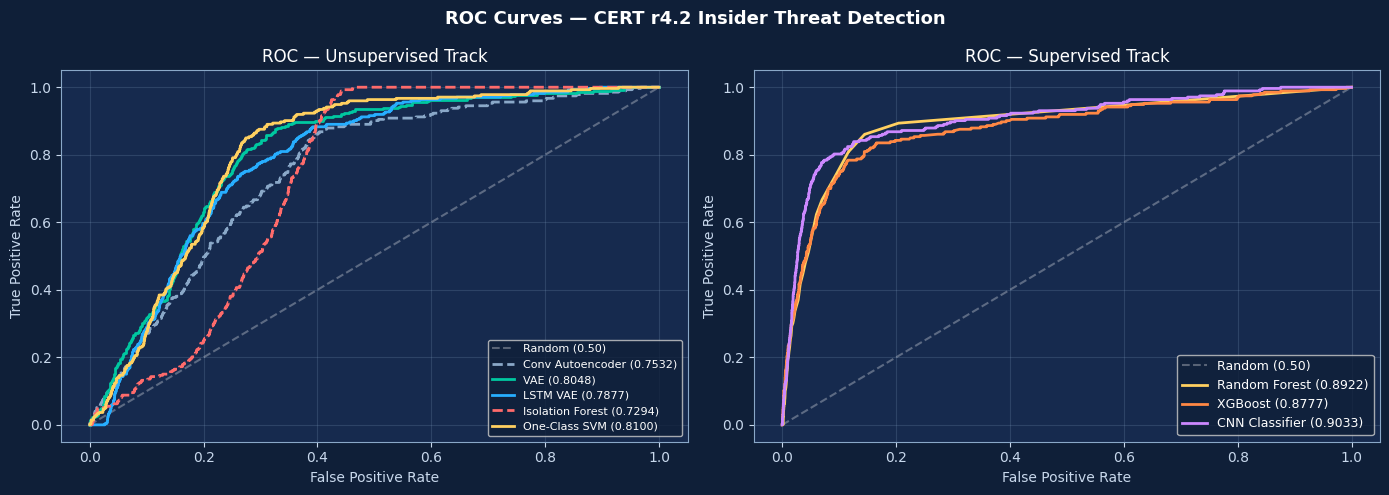

ROC curves saved to roc_curves.png


In [17]:
print('EVALUATION SUMMARY')

model_results = {
    'Conv Autoencoder' : {'track': 'unsupervised', 'AUC': auc_conv_ae,    'AP': ap_conv_ae,    'F1': None},
    'VAE'              : {'track': 'unsupervised', 'AUC': auc_vae,        'AP': ap_vae,        'F1': None},
    'LSTM VAE'         : {'track': 'unsupervised', 'AUC': auc_lstm_vae,   'AP': ap_lstm_vae,   'F1': None},
    'Isolation Forest' : {'track': 'unsupervised', 'AUC': auc_iso_forest, 'AP': ap_iso_forest, 'F1': None},
    'One-Class SVM'    : {'track': 'unsupervised', 'AUC': auc_ocsvm,      'AP': ap_ocsvm,      'F1': None},
    'Random Forest'    : {'track': 'supervised',   'AUC': auc_rf,         'AP': ap_rf,         'F1': f1_rf},
    'XGBoost'          : {'track': 'supervised',   'AUC': auc_xgb,        'AP': ap_xgb,        'F1': f1_xgb},
    'CNN Classifier'   : {'track': 'supervised',   'AUC': auc_cnn,        'AP': ap_cnn,        'F1': f1_cnn},
}

results_df = pd.DataFrame(model_results).T[['track', 'AUC', 'AP', 'F1']]
results_df.index.name = 'Model'
print(results_df.to_string())

best_unsupervised_model = max(
    (m for m, v in model_results.items() if v['track'] == 'unsupervised'),
    key=lambda m: model_results[m]['AUC']
)
best_supervised_model = max(
    (m for m, v in model_results.items() if v['track'] == 'supervised'),
    key=lambda m: model_results[m]['AUC']
)
print(f'\nBest unsupervised: {best_unsupervised_model}  (AUC={model_results[best_unsupervised_model]["AUC"]:.4f})')
print(f'Best supervised  : {best_supervised_model}  (AUC={model_results[best_supervised_model]["AUC"]:.4f})')

# Extended supervised metrics at optimal thresholds (precision, recall, F1) are more informative than accuracy due to the extreme class imbalance (0.13% positive class). 
# We'll find the threshold that maximises F1 score for each model and report the corresponding precision, recall, and F1 at that threshold, along with the ROC-AUC and Average Precision for reference.
print('\n' + '=' * 60)
print('SUPERVISED EXTENDED METRICS (optimal threshold per model)')
print('=' * 60)
print('NOTE: Accuracy omitted — misleading at 0.13% positive class')
print()

def find_optimal_threshold(true_labels, predicted_proba):
    """Find the decision threshold that maximises F1 score."""
    candidate_thresholds = np.linspace(0.01, 0.99, 200)
    best_threshold, best_f1 = 0.5, 0.0
    for threshold in candidate_thresholds:
        predicted = (predicted_proba >= threshold).astype(int)
        current_f1 = f1_score(true_labels, predicted, zero_division=0)
        if current_f1 > best_f1:
            best_f1, best_threshold = current_f1, threshold
    return best_threshold, best_f1


for model_name, predicted_proba in [
    ('Random Forest',  rf_predicted_proba),
    ('XGBoost',        xgb_predicted_proba),
    ('CNN Classifier', cnn_predicted_proba),
]:
    optimal_threshold, _ = find_optimal_threshold(test_labels, predicted_proba)
    optimal_predictions  = (predicted_proba >= optimal_threshold).astype(int)
    print(f'{model_name} (threshold = {optimal_threshold:.2f})')
    print(f'  Precision     : {precision_score(test_labels, optimal_predictions, zero_division=0):.4f}')
    print(f'  Recall        : {recall_score(test_labels, optimal_predictions, zero_division=0):.4f}')
    print(f'  F1 Score      : {f1_score(test_labels, optimal_predictions, zero_division=0):.4f}')
    print(f'  ROC-AUC       : {roc_auc_score(test_labels, predicted_proba):.4f}')
    print(f'  Avg Precision : {average_precision_score(test_labels, predicted_proba):.4f}')
    print()

# Unsupervised metrics 
print('=' * 60)
print('UNSUPERVISED METRICS')
print('=' * 60)
positive_base_rate = test_labels.mean()
for model_name, model_auc, model_ap in [
    ('Conv Autoencoder', auc_conv_ae,    ap_conv_ae),
    ('VAE',              auc_vae,        ap_vae),
    ('LSTM VAE',         auc_lstm_vae,   ap_lstm_vae),
    ('Isolation Forest', auc_iso_forest, ap_iso_forest),
    ('One-Class SVM',    auc_ocsvm,      ap_ocsvm),
]:
    precision_lift = model_ap / positive_base_rate if positive_base_rate > 0 else 0
    print(f'{model_name}')
    print(f'  ROC-AUC       : {model_auc:.4f}')
    print(f'  Avg Precision : {model_ap:.4f}  ({precision_lift:.1f}x lift over random {positive_base_rate:.4f})')
    print()

# Conv VAE vs LSTM VAE 
print('=' * 60)
print('Conv VAE (spatial) vs LSTM VAE (sequential)')
print('=' * 60)
print(f'Conv VAE   96x7 image    ->  AUC: {auc_vae:.4f}')
print(f'LSTM VAE   48x7 GRU seq  ->  AUC: {auc_lstm_vae:.4f}')
auc_gap = auc_lstm_vae - auc_vae
if   auc_gap >  0.005: print(f'LSTM wins by {auc_gap:.4f}')
elif auc_gap < -0.005: print(f'Conv wins by {abs(auc_gap):.4f}')
else:                  print(f'No significant difference ({auc_gap:+.4f})')

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0F1F38')
for ax in axes:
    ax.set_facecolor('#162A4E')
    for spine in ax.spines.values(): spine.set_edgecolor('#8AA8C8')
    ax.tick_params(colors='#C8D8EC')
    ax.xaxis.label.set_color('#C8D8EC')
    ax.yaxis.label.set_color('#C8D8EC')
    ax.title.set_color('white')

unsupervised_roc_series = [
    ('Conv Autoencoder', conv_ae_anomaly_scores,         '#8AA8C8', '--'),
    ('VAE',              vae_anomaly_scores,              '#00C8A0', '-'),
    ('LSTM VAE',         lstm_vae_anomaly_scores,         '#27AEFF', '-'),
    ('Isolation Forest', isolation_forest_anomaly_scores, '#FF6B6B', '--'),
    ('One-Class SVM',    ocsvm_anomaly_scores,            '#FFD060', '-'),
]
ax = axes[0]
ax.plot([0, 1], [0, 1], 'w--', alpha=0.3, label='Random (0.50)')
for model_name, scores, colour, linestyle in unsupervised_roc_series:
    fpr, tpr, _ = roc_curve(test_labels, scores)
    ax.plot(fpr, tpr, color=colour, lw=2, linestyle=linestyle,
            label=f'{model_name} ({roc_auc_score(test_labels, scores):.4f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Unsupervised Track')
ax.legend(fontsize=8, facecolor='#0F1F38', labelcolor='white', framealpha=0.8)
ax.grid(True, alpha=0.2, color='#8AA8C8')

supervised_roc_series = [
    ('Random Forest',  rf_predicted_proba,  '#FFD060', '-'),
    ('XGBoost',        xgb_predicted_proba, '#FF8844', '-'),
    ('CNN Classifier', cnn_predicted_proba, '#CC88FF', '-'),
]
ax = axes[1]
ax.plot([0, 1], [0, 1], 'w--', alpha=0.3, label='Random (0.50)')
for model_name, proba, colour, linestyle in supervised_roc_series:
    fpr, tpr, _ = roc_curve(test_labels, proba)
    ax.plot(fpr, tpr, color=colour, lw=2, linestyle=linestyle,
            label=f'{model_name} ({roc_auc_score(test_labels, proba):.4f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Supervised Track')
ax.legend(fontsize=9, facecolor='#0F1F38', labelcolor='white', framealpha=0.8)
ax.grid(True, alpha=0.2, color='#8AA8C8')

plt.suptitle('ROC Curves — CERT r4.2 Insider Threat Detection',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0F1F38')
plt.show()
print('ROC curves saved to roc_curves.png')
